In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.patches as mpatches

In [2]:
#loading the data set
mlb = pd.read_csv("mlb_data_for_project.csv") # MLB performance data split between home and away from 2022-2025
songs = pd.read_csv("song_data_for_project.csv") # Song data describing various properties of the songs
walkups = pd.read_csv("walkup_songs_for_project.csv") # Walkup song data indicating which song each player used in a given year
bio = pd.read_csv("biographical_data_for_project.csv") # Biographical data about each player
targets = pd.read_csv("submission_ids_for_project.csv")  # the 9 players

In [3]:
print("MLB data shape:", mlb.shape)
print("Song data shape:", songs.shape)
print("Walkups shape:", walkups.shape)
print("Bio shape:", bio.shape)
print("Targets shape:", targets.shape)

MLB data shape: (5234, 49)
Song data shape: (400727, 19)
Walkups shape: (2679, 3)
Bio shape: (859, 9)
Targets shape: (9, 1)


In [4]:
# first 5 rows of our data
mlb.head()

,SEASON,PLAYER_ID,HOME_AWAY,G,PA,AB,H,X1B,X2B,X3B,...,IFFB.,HR.FB,IFH.,BUH.,PULL.,CENT.,OPPO.,SOFT.,MED.,HARD.
0,2022,5cc30873a52a6a8e780085c2fce53f97,home,53,169,143,35,20,5,0,...,0.196721,0.163934,0.052632,0.0,0.523810,0.293651,0.182540,0.190476,0.444444,0.365079
1,2022,eb09596e4b17b3dbd2678ed016c2328f,home,56,211,193,59,49,6,0,...,0.027778,0.111111,0.039474,0.0,0.328767,0.383562,0.287671,0.102740,0.650685,0.246575
2,2022,3312c6017368dd2f720b1161bbbf5867,home,73,263,236,57,32,18,2,...,0.128205,0.064103,0.033898,0.0,0.390110,0.390110,0.219780,0.153846,0.494505,0.351648
3,2022,1c614b599470f5c2df9170ee534a6208,home,71,265,229,46,25,11,0,...,0.130952,0.119048,0.071429,1.0,0.449438,0.353933,0.196629,0.168539,0.455056,0.376404
4,2022,fee7b40d2e6119a0e5b5d0cd955b48e5,home,66,268,240,59,41,12,0,...,0.134615,0.115385,0.031250,0.0,0.368984,0.331551,0.299465,0.149733,0.540107,0.310160


In [5]:
songs.head()

,ID,NAME,ARTISTS,POPULARITY,DURATION_MS,EXPLICIT,RELEASE_DATE,DANCEABILITY,ENERGY,KEY,LOUDNESS,MODE,SPEECHINESS,ACOUSTICNESS,INSTRUMENTALNESS,LIVENESS,VALENCE,TEMPO,TIME_SIGNATURE
0,0eaeb09681b1acebea33cfdc6c34257d,Bring It On Home To Me,['Sam Cooke'],65,165280.0,0,1960-01-01,0.482,0.569,0,-5.897,1,0.0328,0.617,0.000,0.1550,0.609,70.843,4
1,f8af68fe724a3f92b13c4147f6834c10,You Send Me,['Sam Cooke'],64,165560.0,0,1960-01-01,0.553,0.291,4,-10.426,0,0.0301,0.878,0.000,0.1290,0.407,96.217,4
2,235b396836509892e8966152f79dd05e,Summertime Blues,['Eddie Cochran'],64,119360.0,0,1960-05-01,0.714,0.886,11,-8.629,0,0.0554,0.116,0.184,0.1800,0.954,156.351,4
3,11218a13831df1b4aba37a3f2b279bf2,Breaking Up Is Hard to Do,['Neil Sedaka'],63,139200.0,0,1960-12-30,0.743,0.799,8,-5.466,0,0.0375,0.699,0.000,0.0635,0.965,116.112,4
4,8218c2c762766797101f33466205a25e,(What A) Wonderful World,['Sam Cooke'],62,129293.0,0,1960-01-01,0.763,0.571,11,-10.552,1,0.0337,0.529,0.000,0.1540,0.936,128.211,4


In [6]:
walkups.head()

,PLAYER_ID,SEASON,WALKUP_SONG_ID
0,2a2b670f48eba7b83f80022064c06c99,2022,6d671b623cbcf54ca349253bc4afbded
1,2a2b670f48eba7b83f80022064c06c99,2023,89041fd4acdca4228fa1cc96456c81e1
2,18c64b1c775f773fd01eb0b73c348efd,2022,a5b351e79abedf065ffc4be03082c2e5
3,18c64b1c775f773fd01eb0b73c348efd,2023,3524369a19b60b8151102e86380d9127
4,18c64b1c775f773fd01eb0b73c348efd,2024,3524369a19b60b8151102e86380d9127


In [7]:
bio.head()

,PLAYER_ID,BIRTH_DATE,BIRTH_COUNTRY,BIRTH_STATE,WEIGHT,HEIGHT,BATS,THROWS,DEBUT
0,60fd54d6c854797c5465246f9b6a1ce6,2000-10-03,USA,GA,185,74,L,R,2022-04-08
1,442b17b81924a2b87d18523498472eee,1987-01-29,Cuba,Cienfuegos,235,75,R,R,2014-03-31
2,a9e36184c13b79c05af92b316cd76375,1999-06-24,Venezuela,Zulia,215,70,L,L,2023-08-22
3,59bcfd7cfe0204b465a9c85b00debbde,1997-12-18,Venezuela,Vargas,205,72,R,R,2018-04-25
4,fc1b0ad395f75db23ac66029fedc0e84,1995-09-02,D.R.,Santiago,210,72,R,R,2018-05-22


In [8]:
targets.head()

,PLAYER_ID
0,34c74e211da3e913d415c04358792d36
1,058551d1d436fa5205bc5cc31b97109c
2,07d4871bf68c5aaaa51526714ee66d3e
3,806c19f1f39c326204f6b7445cf60b01
4,86e6ecb8b605bea244f4aa2ed7eedd99


In [9]:
mlb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5234 entries, 0 to 5233
Data columns (total 49 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEASON     5234 non-null   int64  
 1   PLAYER_ID  5234 non-null   object 
 2   HOME_AWAY  5234 non-null   object 
 3   G          5234 non-null   int64  
 4   PA         5234 non-null   int64  
 5   AB         5234 non-null   int64  
 6   H          5234 non-null   int64  
 7   X1B        5234 non-null   int64  
 8   X2B        5234 non-null   int64  
 9   X3B        5234 non-null   int64  
 10  HR         5234 non-null   int64  
 11  R          5234 non-null   int64  
 12  RBI        5234 non-null   int64  
 13  BB         5234 non-null   int64  
 14  IBB        5234 non-null   int64  
 15  SO         5234 non-null   int64  
 16  HBP        5234 non-null   int64  
 17  SF         5234 non-null   int64  
 18  SH         5234 non-null   int64  
 19  GDP        5234 non-null   int64  
 20  SB      

In [10]:
songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400727 entries, 0 to 400726
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                400727 non-null  object 
 1   NAME              400715 non-null  object 
 2   ARTISTS           400727 non-null  object 
 3   POPULARITY        400727 non-null  int64  
 4   DURATION_MS       400727 non-null  float64
 5   EXPLICIT          400727 non-null  int64  
 6   RELEASE_DATE      400727 non-null  object 
 7   DANCEABILITY      400727 non-null  float64
 8   ENERGY            400727 non-null  float64
 9   KEY               400727 non-null  int64  
 10  LOUDNESS          400727 non-null  float64
 11  MODE              400727 non-null  int64  
 12  SPEECHINESS       400727 non-null  float64
 13  ACOUSTICNESS      400727 non-null  float64
 14  INSTRUMENTALNESS  400727 non-null  float64
 15  LIVENESS          400727 non-null  float64
 16  VALENCE           40

In [11]:
walkups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2679 entries, 0 to 2678
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PLAYER_ID       2679 non-null   object
 1   SEASON          2679 non-null   int64 
 2   WALKUP_SONG_ID  2624 non-null   object
dtypes: int64(1), object(2)
memory usage: 41.9+ KB


In [12]:
bio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 859 entries, 0 to 858
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PLAYER_ID      859 non-null    object
 1   BIRTH_DATE     859 non-null    object
 2   BIRTH_COUNTRY  859 non-null    object
 3   BIRTH_STATE    829 non-null    object
 4   WEIGHT         859 non-null    int64 
 5   HEIGHT         859 non-null    int64 
 6   BATS           859 non-null    object
 7   THROWS         859 non-null    object
 8   DEBUT          859 non-null    object
dtypes: int64(2), object(7)
memory usage: 37.0+ KB


In [13]:
bio['DEBUT'] = pd.to_datetime(bio['DEBUT'], errors='coerce')

In [14]:
targets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   PLAYER_ID  9 non-null      object
dtypes: object(1)
memory usage: 108.0+ bytes


In [15]:
mlb.describe()

,SEASON,G,PA,AB,H,X1B,X2B,X3B,HR,R,...,IFFB.,HR.FB,IFH.,BUH.,PULL.,CENT.,OPPO.,SOFT.,MED.,HARD.
count,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,...,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000,5234.000000
mean,2023.489683,37.329576,139.136416,124.621895,30.531716,19.776462,6.029996,0.509553,4.215705,16.402178,...,0.098311,0.098391,0.064711,0.101515,0.404734,0.344902,0.239855,0.165835,0.529510,0.294147
std,1.125758,25.406560,107.878311,96.261886,26.113407,16.983870,5.701477,0.975529,4.943856,14.744621,...,0.107796,0.099966,0.090037,0.255983,0.134586,0.122029,0.109804,0.096591,0.133873,0.119798
min,2022.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.000000,13.000000,39.000000,35.000000,7.000000,5.000000,1.000000,0.000000,0.000000,4.000000,...,0.021277,0.000000,0.000000,0.000000,0.347826,0.300000,0.194030,0.123810,0.478261,0.243243
50%,2023.000000,36.000000,118.000000,106.000000,24.000000,16.000000,4.000000,0.000000,2.000000,12.000000,...,0.083333,0.088235,0.052016,0.000000,0.406321,0.345679,0.238206,0.159163,0.526316,0.303571
75%,2025.000000,61.000000,229.000000,204.000000,51.000000,32.000000,10.000000,1.000000,7.000000,26.000000,...,0.137931,0.147059,0.086957,0.000000,0.466667,0.389576,0.284757,0.198892,0.583333,0.357143
max,2025.000000,84.000000,384.000000,350.000000,118.000000,90.000000,32.000000,12.000000,33.000000,79.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
songs.describe()

,POPULARITY,DURATION_MS,EXPLICIT,DANCEABILITY,ENERGY,KEY,LOUDNESS,MODE,SPEECHINESS,ACOUSTICNESS,INSTRUMENTALNESS,LIVENESS,VALENCE,TEMPO,TIME_SIGNATURE
count,400727.000000,4.007270e+05,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000,400727.000000
mean,32.624695,2.314064e+05,0.057847,0.577325,0.588066,5.247400,-9.302987,0.645699,0.098689,0.379291,0.077694,0.214267,0.555792,119.797590,3.893990
std,17.072013,1.150816e+05,0.233455,0.161671,0.234582,3.533589,4.563005,0.478302,0.162530,0.320429,0.222014,0.187276,0.253919,29.309134,0.430143
min,1.000000,1.470800e+04,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,1.816810e+05,0.000000,0.471000,0.418000,2.000000,-11.689000,0.000000,0.033400,0.069000,0.000000,0.096800,0.352000,96.993000,4.000000
50%,32.000000,2.212130e+05,0.000000,0.589000,0.603000,5.000000,-8.421000,1.000000,0.043800,0.314000,0.000010,0.137000,0.565000,119.362000,4.000000
75%,44.000000,2.661330e+05,0.000000,0.695000,0.780000,8.000000,-6.044000,1.000000,0.076800,0.665000,0.002200,0.279000,0.770000,137.909000,4.000000
max,100.000000,5.621218e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.969000,0.996000,1.000000,1.000000,1.000000,246.381000,5.000000


In [17]:
# Missing Values
missing_counts = mlb.isnull().sum()
print(missing_counts)

SEASON       0
PLAYER_ID    0
HOME_AWAY    0
G            0
PA           0
AB           0
H            0
X1B          0
X2B          0
X3B          0
HR           0
R            0
RBI          0
BB           0
IBB          0
SO           0
HBP          0
SF           0
SH           0
GDP          0
SB           0
CS           0
AVG          0
BB.          0
K.           0
BB.K         0
OBP          0
SLG          0
OPS          0
ISO          0
BABIP        0
WRC          0
WRAA         0
WOBA         0
WRC.         0
GB.FB        0
LD.          0
GB.          0
FB.          0
IFFB.        0
HR.FB        0
IFH.         0
BUH.         0
PULL.        0
CENT.        0
OPPO.        0
SOFT.        0
MED.         0
HARD.        0
dtype: int64


In [18]:
#Missing Values
missing_counts = songs.isnull().sum()
print(missing_counts)

ID                   0
NAME                12
ARTISTS              0
POPULARITY           0
DURATION_MS          0
EXPLICIT             0
RELEASE_DATE         0
DANCEABILITY         0
ENERGY               0
KEY                  0
LOUDNESS             0
MODE                 0
SPEECHINESS          0
ACOUSTICNESS         0
INSTRUMENTALNESS     0
LIVENESS             0
VALENCE              0
TEMPO                0
TIME_SIGNATURE       0
dtype: int64


In [19]:
# “Twelve songs were missing titles in the song dataset. Since these records still contained valid audio features and artist information, we replaced missing titles with the placeholder ‘Unknown Song.’ This ensured no data was lost for modeling while maintaining interpretability for recommendation outputs.
songs['NAME'] = songs['NAME'].fillna('Unknown Song')

In [20]:
#Missing values
missing_counts = walkups.isnull().sum()
print(missing_counts)

PLAYER_ID          0
SEASON             0
WALKUP_SONG_ID    55
dtype: int64


In [21]:
# filling empty walkup_song_id with -1
walkups['WALKUP_SONG_ID'] = walkups['WALKUP_SONG_ID'].fillna(-1)

In [22]:
#Missing Values
missing_counts = bio.isnull().sum()
print(missing_counts)

PLAYER_ID         0
BIRTH_DATE        0
BIRTH_COUNTRY     0
BIRTH_STATE      30
WEIGHT            0
HEIGHT            0
BATS              0
THROWS            0
DEBUT             0
dtype: int64


In [23]:
# filling empty places with Unknown
bio['BIRTH_STATE'] = bio['BIRTH_STATE'].fillna('Unknown')

In [24]:
#Missing Values
missing_counts=targets.isnull().sum()
print(missing_counts)

PLAYER_ID    0
dtype: int64


In [25]:
# If the MLB file has multiple rows per player-season-home/away, aggregate first
if {'PLAYER_ID', 'SEASON', 'HOME_AWAY'}.issubset(mlb.columns):
    mlb = (
        mlb.groupby(['PLAYER_ID', 'SEASON', 'HOME_AWAY'], as_index=False)
           .mean(numeric_only=True)   # aggregate numeric stats
    )
    print(f"MLB aggregated: {mlb.shape[0]} rows after grouping")

MLB aggregated: 5234 rows after grouping


In [26]:
# merging all dataset and forming new dataset
merged = (
    mlb.merge(walkups, on=['PLAYER_ID', 'SEASON'], how='left')
       .merge(bio, on='PLAYER_ID', how='left')
       .merge(songs, left_on='WALKUP_SONG_ID', right_on='ID', how='left')
)


In [27]:
merged.shape
merged.columns
merged.head()


,PLAYER_ID,SEASON,HOME_AWAY,G,PA,AB,H,X1B,X2B,X3B,...,KEY,LOUDNESS,MODE,SPEECHINESS,ACOUSTICNESS,INSTRUMENTALNESS,LIVENESS,VALENCE,TEMPO,TIME_SIGNATURE
0,001dc9773644fd3be48a8777ff032c9c,2022,away,2.0,2.0,2.0,1.0,0.0,0.0,0.0,...,9.0,-25.326,0.0,0.0579,0.9730,0.000053,0.0794,0.347,103.147,4.0
1,01337e3e60ed840c35403950be852f7c,2022,away,79.0,350.0,317.0,99.0,59.0,24.0,1.0,...,1.0,-7.088,1.0,0.0302,0.0222,0.000000,0.3320,0.572,144.139,4.0
2,01337e3e60ed840c35403950be852f7c,2022,home,71.0,294.0,261.0,73.0,43.0,13.0,0.0,...,1.0,-7.088,1.0,0.0302,0.0222,0.000000,0.3320,0.572,144.139,4.0
3,01337e3e60ed840c35403950be852f7c,2023,away,65.0,295.0,271.0,64.0,36.0,15.0,0.0,...,1.0,-7.088,1.0,0.0302,0.0222,0.000000,0.3320,0.572,144.139,4.0
4,01337e3e60ed840c35403950be852f7c,2023,home,73.0,306.0,272.0,76.0,53.0,6.0,0.0,...,1.0,-7.088,1.0,0.0302,0.0222,0.000000,0.3320,0.572,144.139,4.0


In [28]:
# Validate merge counts 
print(f"After full merge: {len(merged)} total rows")
print(f"Unique players: {merged['PLAYER_ID'].nunique()}")

After full merge: 5234 total rows
Unique players: 1056


In [29]:
merged['ID'] = merged['ID'].astype(str)
mask_missing_id = merged['ID'].isin(['nan', 'NaN', 'None', ''])
merged.loc[mask_missing_id, 'ID'] = [
    f'Unknown_{i}' for i in range(len(merged[mask_missing_id]))
]
print(f"Cleaned song IDs — unique count: {merged['ID'].nunique()}")

# Feature-type review
# Convert categorical attributes to 'category' dtype
categorical_cols = [col for col in ['BATS', 'THROWS', 'TEAM'] if col in merged.columns]
for col in categorical_cols:
    merged[col] = merged[col].astype('category')
print(f"Converted to categorical: {categorical_cols}")

# Optional sanity check
print("Final dataset info summary:")
print(merged.info())

Cleaned song IDs — unique count: 1850
Converted to categorical: ['BATS', 'THROWS']
Final dataset info summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5234 entries, 0 to 5233
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PLAYER_ID         5234 non-null   object        
 1   SEASON            5234 non-null   int64         
 2   HOME_AWAY         5234 non-null   object        
 3   G                 5234 non-null   float64       
 4   PA                5234 non-null   float64       
 5   AB                5234 non-null   float64       
 6   H                 5234 non-null   float64       
 7   X1B               5234 non-null   float64       
 8   X2B               5234 non-null   float64       
 9   X3B               5234 non-null   float64       
 10  HR                5234 non-null   float64       
 11  R                 5234 non-null   float64       
 12  RBI               523

                  Missing_Count  Missing_Percentage
BIRTH_DATE                  520             9.93504
BIRTH_STATE                 520             9.93504
WEIGHT                      520             9.93504
HEIGHT                      520             9.93504
BATS                        520             9.93504
THROWS                      520             9.93504
DEBUT                       520             9.93504
BIRTH_COUNTRY               520             9.93504
LOUDNESS                    106             2.02522
TEMPO                       106             2.02522
VALENCE                     106             2.02522
LIVENESS                    106             2.02522
INSTRUMENTALNESS            106             2.02522
ACOUSTICNESS                106             2.02522
SPEECHINESS                 106             2.02522
MODE                        106             2.02522
RELEASE_DATE                106             2.02522
KEY                         106             2.02522
ENERGY      

<Figure size 1000x500 with 0 Axes>

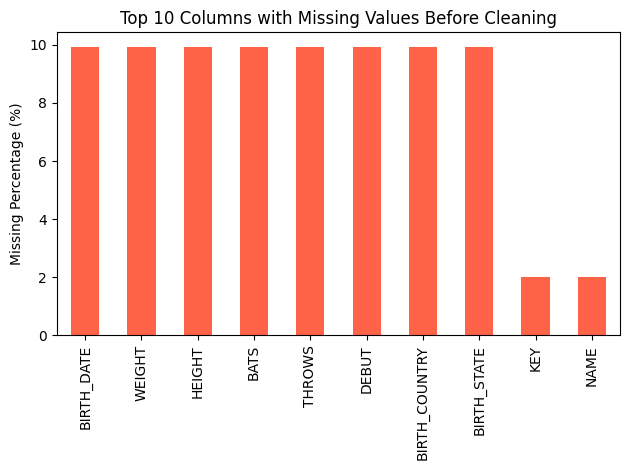

In [30]:
# list of missing value columns
missing_summary = (
    merged.isna().sum().to_frame("Missing_Count")
    .assign(Missing_Percentage=lambda x: 100 * x["Missing_Count"] / len(merged))
    .query("Missing_Count > 0")
    .sort_values("Missing_Percentage", ascending=False)
)
print(missing_summary)

plt.figure(figsize=(10,5))
missing_summary.sort_values('Missing_Percentage', ascending=False).head(10).plot(
    kind='bar', y='Missing_Percentage', legend=False, color='tomato')
plt.ylabel('Missing Percentage (%)')
plt.title('Top 10 Columns with Missing Values Before Cleaning')
plt.tight_layout()
plt.show()

In [31]:
# Handle missing biographical data safely for categorical columns
bio_fill_cols = ['BIRTH_DATE', 'BIRTH_COUNTRY', 'BIRTH_STATE', 'BATS', 'THROWS']

for col in bio_fill_cols:
    if col in merged.columns:
        # If column is categorical, add 'Unknown' to allowed categories first
        if str(merged[col].dtype) == 'category':
            merged[col] = merged[col].cat.add_categories(['Unknown']).fillna('Unknown')
        else:
            merged[col] = merged[col].fillna('Unknown')

print("Missing biographical data handled successfully.")


Missing biographical data handled successfully.


In [32]:
# For numeric attributes like height/weight:
for col in ['HEIGHT', 'WEIGHT']:
    if col in merged.columns:
        merged[col] = merged[col].fillna(merged[col].median())


In [33]:
# If players don’t have a song ID or song info:
# Players without walkup songs
merged['WALKUP_SONG_ID'] = merged['WALKUP_SONG_ID'].fillna(-1)  # -1 means “No Song”

# Song text attributes
for col in ['NAME', 'ARTISTS']:
    if col in merged.columns:
        merged[col] = merged[col].fillna('Unknown')

# Song numeric/audio features
song_num_cols = [
    'DURATION_MS', 'POPULARITY', 'DANCEABILITY', 'ENERGY', 'LOUDNESS',
    'SPEECHINESS', 'ACOUSTICNESS', 'INSTRUMENTALNESS', 'LIVENESS',
    'VALENCE', 'TEMPO', 'TIME_SIGNATURE'
]
for col in song_num_cols:
    if col in merged.columns:
        merged[col] = merged[col].fillna(merged[col].median())


In [34]:
#Fill MLB Stats (just in case)
#These usually won’t be missing, but check anyway:
mlb_stats = ['OPS', 'OBP', 'SLG', 'AVG']
for col in mlb_stats:
    if col in merged.columns:
        merged[col] = merged[col].fillna(merged[col].mean())


In [35]:
print("Missing values after filling:")
print(merged.isna().sum().sort_values(ascending=False).head(15))


Missing values after filling:
DEBUT             520
MODE              106
EXPLICIT          106
RELEASE_DATE      106
KEY               106
CENT.               0
OPPO.               0
SOFT.               0
PULL.               0
MED.                0
BATS                0
HARD.               0
WALKUP_SONG_ID      0
BUH.                0
IFH.                0
dtype: int64


In [36]:
# Fill DEBUT (player debut date) 
if 'TEAM' in merged.columns:
    merged['DEBUT'] = merged.groupby('TEAM')['DEBUT'].transform(lambda x: x.fillna(x.median()))

merged['DEBUT'] = merged['DEBUT'].fillna(merged['DEBUT'].median())

# Fill missing Song ID
merged['ID'] = merged['ID'].astype(str)
mask_missing_id = merged['ID'].isin(['nan', 'NaN', 'None', ''])
merged.loc[mask_missing_id, 'ID'] = [f'Unknown_{i}' for i in range(len(merged[mask_missing_id]))] 

# Handle missing song metadata columns
if 'KEY' in merged.columns:
    merged['KEY'] = merged['KEY'].fillna(merged['KEY'].mode()[0])

if 'EXPLICIT' in merged.columns:
    # Convert to binary if not already
    merged['EXPLICIT'] = merged['EXPLICIT'].fillna(0).astype(int)

if 'MODE' in merged.columns:
    merged['MODE'] = merged['MODE'].fillna(merged['MODE'].mode()[0])

if 'RELEASE_DATE' in merged.columns:
    merged['RELEASE_DATE'] = pd.to_datetime(merged['RELEASE_DATE'], errors='coerce')
    median_date = merged['RELEASE_DATE'].dropna().median()
    merged['RELEASE_DATE'] = merged['RELEASE_DATE'].fillna(median_date)



In [37]:
print("Missing values after filling:")
print(merged.isna().sum().sort_values(ascending=False).head(15))


Missing values after filling:
PLAYER_ID         0
WALKUP_SONG_ID    0
THROWS            0
BATS              0
HEIGHT            0
WEIGHT            0
BIRTH_STATE       0
BIRTH_COUNTRY     0
BIRTH_DATE        0
HARD.             0
IFFB.             0
MED.              0
SOFT.             0
OPPO.             0
CENT.             0
dtype: int64


In [38]:
# Save the cleaned merged dataset to CSV 
merged.to_csv("merged_cleaned_dataset.csv", index=False)
print("Merged dataset successfully saved as 'merged_cleaned_dataset.csv'")


Merged dataset successfully saved as 'merged_cleaned_dataset.csv'


In [39]:
new_data = pd.read_csv("merged_cleaned_dataset.csv") 

In [40]:
print(new_data.isnull().sum())

PLAYER_ID           0
SEASON              0
HOME_AWAY           0
G                   0
PA                  0
                   ..
INSTRUMENTALNESS    0
LIVENESS            0
VALENCE             0
TEMPO               0
TIME_SIGNATURE      0
Length: 77, dtype: int64


In [41]:

# Control variable for player ability
if 'OPS_HOME' in new_data.columns and 'OPS_AWAY' in new_data.columns:
    new_data['HOME_OPS'] = new_data['OPS_HOME']
    new_data['AWAY_OPS'] = new_data['OPS_AWAY']
    new_data['OPS_DELTA'] = new_data['HOME_OPS'] - new_data['AWAY_OPS']
else:
    new_data['HOME_OPS'] = new_data['OPS']
    new_data['AWAY_OPS'] = new_data['OPS']

# Player-level features
new_data['AGE'] = 2025 - pd.to_datetime(new_data['BIRTH_DATE'], errors='coerce').dt.year
new_data['AGE'] = new_data['AGE'].fillna(new_data['AGE'].median())

player_freq = new_data['PLAYER_ID'].value_counts(normalize=True)
new_data['PLAYER_FREQ'] = new_data['PLAYER_ID'].map(player_freq)

# Song features to use (filter to existing ones)
song_features = [
    'DURATION_MS','POPULARITY','DANCEABILITY','ENERGY','LOUDNESS',
    'SPEECHINESS','ACOUSTICNESS','INSTRUMENTALNESS','LIVENESS',
    'VALENCE','TEMPO','TIME_SIGNATURE','MODE','KEY'
]
song_features = [col for col in song_features if col in new_data.columns]

# Drop rows missing essential performance data
new_data = new_data.dropna(subset=['HOME_OPS', 'AWAY_OPS'])




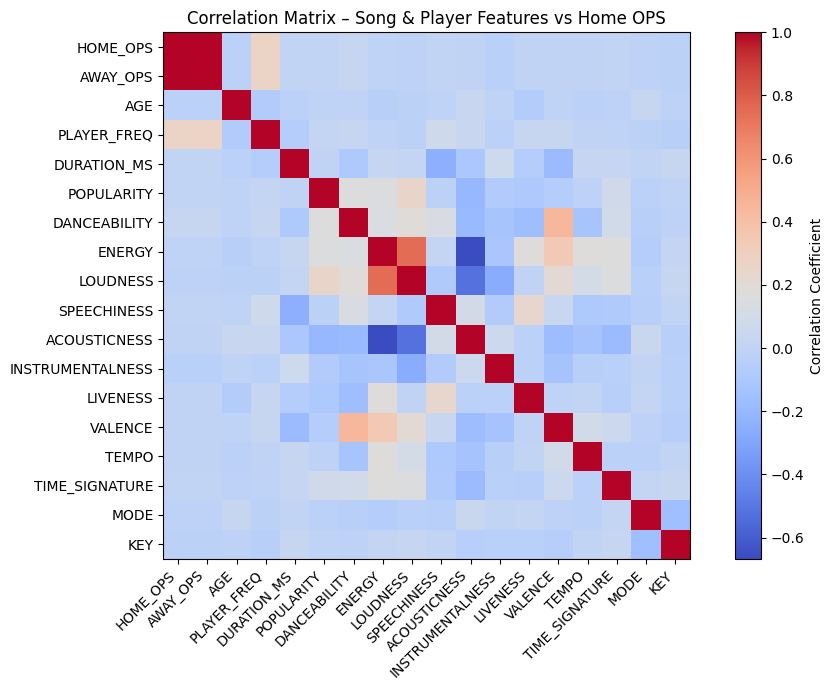

In [42]:
corr_features = ['HOME_OPS','AWAY_OPS','AGE','PLAYER_FREQ'] + song_features
corr = new_data[corr_features].corr(numeric_only=True)

plt.figure(figsize=(10,7))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix – Song & Player Features vs Home OPS")
plt.tight_layout()
plt.show()


Test R²: 0.894
Test RMSE: 0.084


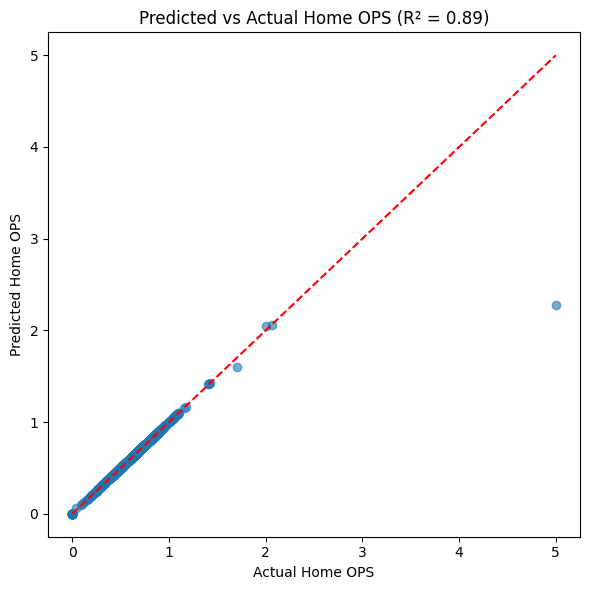

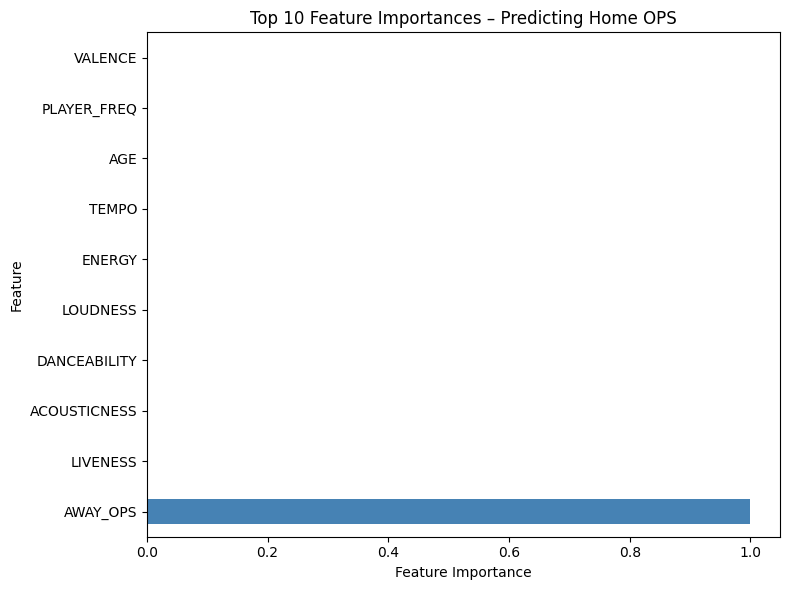

In [44]:
# Prepare features & target
X = new_data[['AWAY_OPS','PLAYER_FREQ','AGE'] + song_features]
y = new_data['HOME_OPS']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test) 
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test R²: {r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Home OPS")
plt.ylabel("Predicted Home OPS")
plt.title(f"Predicted vs Actual Home OPS (R² = {r2:.2f})")
plt.tight_layout()
plt.show()

importances = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(8,6))
importances.nlargest(10).plot(kind='barh', color='steelblue')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances – Predicting Home OPS")
plt.tight_layout()
plt.show()


In [45]:

# Use only top 150 most popular songs as candidates
candidate_songs = (
    new_data.drop_duplicates('ID')
            .sort_values('POPULARITY', ascending=False)
            .head(150)
)

recommendations = []

for pid in targets['PLAYER_ID']:
    player_data = new_data[new_data['PLAYER_ID'] == pid].sort_values('SEASON', ascending=False).head(1)
    if player_data.empty:
        continue

    base_features = player_data[['AWAY_OPS','PLAYER_FREQ','AGE']].values[0]
    base_home_ops = player_data['HOME_OPS'].values[0]

    # Vectorized prediction for all candidate songs
    X_candidates = np.hstack([
        np.tile(base_features, (len(candidate_songs), 1)),
        candidate_songs[song_features].values
    ])

    pred_ops = rf.predict(X_candidates)
    deltas = pred_ops - base_home_ops

    candidate_songs_copy = candidate_songs.copy()
    candidate_songs_copy['PREDICTED_OPS'] = pred_ops
    candidate_songs_copy['DELTA'] = deltas

    top_song = candidate_songs_copy.sort_values('DELTA', ascending=False).iloc[0]

    recommendations.append({
        'PLAYER_ID': pid,
        'RECOMMENDED_SONG_ID': top_song['ID'],
        'RECOMMENDED_SONG_NAME': top_song['NAME'],
        'ARTISTS': top_song['ARTISTS'],
        'PREDICTED_OPS': top_song['PREDICTED_OPS'],
        'DELTA': top_song['DELTA']
    })

    # Save smaller candidate table for justification (top 20)
    candidate_songs_copy.sort_values('DELTA', ascending=False).head(20).to_csv(
        f"example_candidate_table_{pid}.csv", index=False
    )

recs_df = pd.DataFrame(recommendations)
recs_df.to_csv("song_recommendations_for_submission.csv", index=False)
print("Song recommendations generated and saved!")


/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: U

Song recommendations generated and saved!


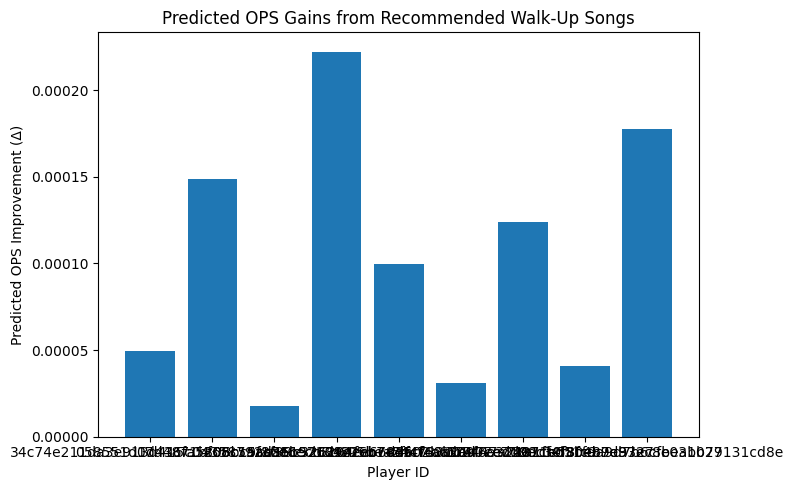

In [46]:
recs_df = pd.read_csv("song_recommendations_for_submission.csv")

plt.figure(figsize=(8,5))
plt.bar(recs_df['PLAYER_ID'].astype(str), recs_df['DELTA'])
plt.xlabel("Player ID")
plt.ylabel("Predicted OPS Improvement (Δ)")
plt.title("Predicted OPS Gains from Recommended Walk-Up Songs")
plt.tight_layout()
plt.show()


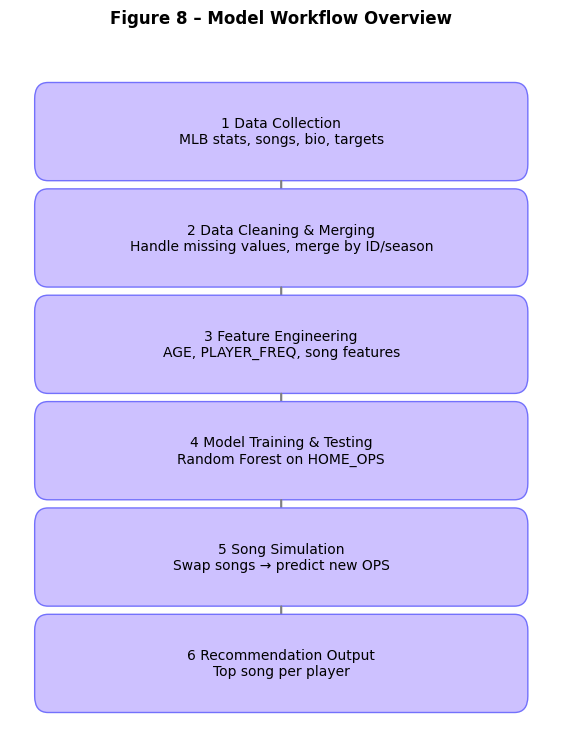

In [48]:
steps = [
    "1️ Data Collection\nMLB stats, songs, bio, targets",
    "2️ Data Cleaning & Merging\nHandle missing values, merge by ID/season",
    "3️ Feature Engineering\nAGE, PLAYER_FREQ, song features",
    "4️ Model Training & Testing\nRandom Forest on HOME_OPS",
    "5️ Song Simulation\nSwap songs → predict new OPS",
    "6️ Recommendation Output\nTop song per player"
]

fig, ax = plt.subplots(figsize=(7, 9))
ax.axis("off")

y = 0.9
for step in steps:
    box = mpatches.FancyBboxPatch((0.15, y), 0.7, 0.08, boxstyle="round,pad=0.02",
                                  facecolor="#CDC1FF", edgecolor="#7371FC")
    ax.add_patch(box)
    ax.text(0.5, y + 0.04, step, ha="center", va="center", fontsize=10, wrap=True)
    if step != steps[-1]:
        ax.arrow(0.5, y - 0.02, 0, -0.05, head_width=0.02, head_length=0.02,
                 fc="gray", ec="gray")
    y -= 0.13

plt.title("Figure 8 – Model Workflow Overview", fontsize=12, weight="bold", pad=20)
plt.show()
